# 1) Dataset y contexto de coste asimétrico

Usaremos el dataset **Breast Cancer Wisconsin** de `sklearn`, con observaciones de tumores de mama.

Fijamos etiquetas binarias como:
- $y=+1$: **maligno** (clase positiva).
- $y=-1$: **benigno** (clase negativa).

En cribado médico, un **falso negativo (FN)** (decir benigno cuando es maligno) suele ser más grave que un falso positivo (FP), por retrasar diagnóstico y tratamiento.

Por eso fijamos un coste asimétrico:
- $C_{FN}=10$
- $C_{FP}=1$

Así penalizamos más los FN en la evaluación del modelo.

In [8]:
import numpy as np  # Operaciones numéricas y utilidades de arrays
import pandas as pd  # Estructuras tabulares para resumir resultados
import matplotlib.pyplot as plt  # Gráficos de curvas y fronteras

from sklearn.datasets import load_breast_cancer  # Dataset de cáncer de mama
from sklearn.model_selection import train_test_split, validation_curve  # Split estratificado y curva de validación por hiperparámetro
from sklearn.pipeline import Pipeline  # Encadena escalado + clasificador en un solo objeto
from sklearn.preprocessing import StandardScaler  # Estandariza variables para SVM
from sklearn.svm import SVC  # Implementación de SVM en sklearn
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score  # Métricas principales de clasificación

RANDOM_STATE = 42  # Semilla para reproducibilidad de los experimentos
CFN = 10  # Coste asignado a cada falso negativo
CFP = 1  # Coste asignado a cada falso positivo

print(f'Configuración: RANDOM_STATE={RANDOM_STATE}, CFN={CFN}, CFP={CFP}')  # Verifica parámetros globales

Configuración: RANDOM_STATE=42, CFN=10, CFP=1


# 3) Variables de entrada $X$

En el experimento principal usaremos las **30 variables** del dataset original.

| Grupo | Variables |
|---|---|
| mean | mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, mean concavity, mean concave points, mean symmetry, mean fractal dimension |
| error | radius error, texture error, perimeter error, area error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error |
| worst | worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points, worst symmetry, worst fractal dimension |

Nota: para la función `plotter`, la frontera se muestra en 2D usando solo un par de variables para interpretación visual.

In [9]:
data = load_breast_cancer(as_frame=True)  # Carga dataset como DataFrame para mantener nombres de columnas
X = data.data.copy()  # Usa las 30 variables originales del dataset
y = np.where(data.target.to_numpy() == 0, 1, -1)  # Reetiqueta: maligno->+1 (target=0), benigno->-1 (target=1)

X_train, X_val, y_train, y_val = train_test_split(  # Divide en train y validación
    X,  # Matriz completa de características (30 dimensiones)
    y,  # Etiquetas binarias en {-1,+1}
    test_size=0.20,  # 20% de datos para validación
    stratify=y,  # Conserva proporciones de clases en ambos subconjuntos
    random_state=RANDOM_STATE  # Hace la partición reproducible
)

print(f'Dimensiones X_train: {X_train.shape} | Dimensiones X_val: {X_val.shape}')  # Verifica tamaños y dimensionalidad
print(f'Proporción y=+1 en train: {(y_train == 1).mean():.3f}')  # Comprueba proporción de positivos en train
print(f'Proporción y=+1 en val:   {(y_val == 1).mean():.3f}')  # Comprueba proporción de positivos en validación

Dimensiones X_train: (455, 30) | Dimensiones X_val: (114, 30)
Proporción y=+1 en train: 0.374
Proporción y=+1 en val:   0.368


# 5) Plan de entrenamiento y criterio en validación

Entrenaremos modelos **SVM lineales** en `train`, variando penalizaciones de coste:
- $C$ (rigidez global del soft-margin)
- $C_+$ (peso de la clase positiva, $y=+1$)
- $C_-$ (peso de la clase negativa, $y=-1$)

Después los juzgaremos en `val` con el **coste medio asimétrico**:
$$
\hat{R}_c = \frac{1}{m_{val}}(C_{FP} FP + C_{FN} FN).
$$

El mejor modelo será el que minimice $\hat{R}_c$ en validación.

In [3]:
def svm_lineal_train(X_train, y_train, C=1.0, C_plus=1.0, C_minus=1.0):  # Entrena SVM lineal con pesos por clase
    eps = 1e-6  # Evita pesos exactamente nulos para mantener estabilidad numérica en SVC
    class_weight = {1: max(float(C_plus), eps), -1: max(float(C_minus), eps)}  # Asigna peso por clase (con cota inferior pequeña)
    model = Pipeline([  # Crea pipeline para evitar fuga de escalado y simplificar uso
        ('scaler', StandardScaler()),  # Ajusta media/desviación en train y transforma cada variable
        ('svc', SVC(kernel='linear', C=C, class_weight=class_weight, random_state=RANDOM_STATE)),  # Define SVM lineal con C y pesos
    ])
    model.fit(X_train, y_train)  # Ajusta el pipeline completo con datos de entrenamiento
    return model  # Devuelve modelo entrenado y listo para predecir

def coste_medio(y_true, y_pred, cfn=CFN, cfp=CFP):  # Calcula coste medio asimétrico por observación
    fp = np.sum((y_true == -1) & (y_pred == 1))  # Cuenta falsos positivos
    fn = np.sum((y_true == 1) & (y_pred == -1))  # Cuenta falsos negativos
    return (cfp * fp + cfn * fn) / len(y_true)  # Aplica definición de coste medio

def scorer(y_true, y_pred, cfn=CFN, cfp=CFP):  # Define score compatible con criterio de minimización de coste
    return -coste_medio(y_true, y_pred, cfn=cfn, cfp=cfp)  # Devuelve negativo para que mayor score signifique mejor

def evalua_modelo(model, X_eval, y_eval, cfn=CFN, cfp=CFP):  # Devuelve métricas completas para evaluar en validación
    y_hat = model.predict(X_eval)  # Obtiene etiquetas predichas por el modelo
    tn = int(np.sum((y_eval == -1) & (y_hat == -1)))  # Cuenta verdaderos negativos
    fp = int(np.sum((y_eval == -1) & (y_hat == 1)))  # Cuenta falsos positivos
    fn = int(np.sum((y_eval == 1) & (y_hat == -1)))  # Cuenta falsos negativos
    tp = int(np.sum((y_eval == 1) & (y_hat == 1)))  # Cuenta verdaderos positivos
    coste_total = cfp * fp + cfn * fn  # Coste agregado de todos los errores
    return {  # Devuelve resumen amplio para comparar modelos
        'accuracy': float(accuracy_score(y_eval, y_hat)),  # Exactitud global
        'recall_positivo': float(recall_score(y_eval, y_hat, pos_label=1, zero_division=0)),  # Sensibilidad en malignos
        'precision_positivo': float(precision_score(y_eval, y_hat, pos_label=1, zero_division=0)),  # Precisión en positivos
        'f1_positivo': float(f1_score(y_eval, y_hat, pos_label=1, zero_division=0)),  # Compromiso precisión/recall
        'TN': tn,  # Verdaderos negativos
        'FP': fp,  # Falsos positivos
        'FN': fn,  # Falsos negativos
        'TP': tp,  # Verdaderos positivos
        'coste_total': float(coste_total),  # Coste total asimétrico
        'coste_medio': float(coste_total / len(y_eval)),  # Coste medio por muestra
    }

In [5]:
# OTRAS FUNCIONES AUXILIARES

def plotter(model, X_plot, y_plot, title=''):  # Dibuja frontera/márgenes/SV usando directamente una X ya en 2D
    x_min, x_max = X_plot.iloc[:, 0].min() - 1.0, X_plot.iloc[:, 0].max() + 1.0  # Define rango del eje x a partir de los datos 2D
    y_min, y_max = X_plot.iloc[:, 1].min() - 0.02, X_plot.iloc[:, 1].max() + 0.02  # Define rango del eje y a partir de los datos 2D
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 320), np.linspace(y_min, y_max, 320))  # Crea rejilla regular para evaluar la función de decisión
    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_plot.columns)  # Construye rejilla con los mismos nombres de columnas del entrenamiento 2D

    z = model.decision_function(grid).reshape(xx.shape)  # Calcula score s(x) sobre la rejilla para trazar contornos

    plt.figure(figsize=(7.2, 5.2))  # Crea figura para la visualización
    plt.contourf(xx, yy, z >= 0, levels=[-0.5, 0.5, 1.5], alpha=0.18, colors=['#4C72B0', '#DD8452'])  # Colorea áreas predichas por clase
    plt.contour(xx, yy, z, levels=[-1, 0, 1], colors=['#2E4A75', 'black', '#8C4B2B'], linestyles=['--', '-', '--'], linewidths=[1.0, 1.8, 1.0])  # Dibuja margen (-1,+1) y frontera (0)

    plt.scatter(X_plot[y_plot == -1].iloc[:, 0], X_plot[y_plot == -1].iloc[:, 1], s=16, c='#4C72B0', alpha=0.70, label='y=-1 (benigno)')  # Puntos de la clase negativa
    plt.scatter(X_plot[y_plot == 1].iloc[:, 0], X_plot[y_plot == 1].iloc[:, 1], s=16, c='#DD8452', alpha=0.70, label='y=+1 (maligno)')  # Puntos de la clase positiva

    svc = model.named_steps['svc']  # Extrae el clasificador SVC del pipeline
    scaler = model.named_steps['scaler']  # Extrae el escalador para volver a la escala original
    sv_original = scaler.inverse_transform(svc.support_vectors_)  # Recupera los vectores soporte en coordenadas originales del gráfico
    plt.scatter(sv_original[:, 0], sv_original[:, 1], s=58, facecolors='none', edgecolors='black', linewidths=0.85, alpha=0.70, label='vectores soporte')  # Rodea SV de forma sutil

    plt.title(title if title else 'Frontera y margen (X en 2D)')  # Título automático o personalizado
    plt.xlabel(X_plot.columns[0])  # Etiqueta eje x usando el nombre real de la primera variable
    plt.ylabel(X_plot.columns[1])  # Etiqueta eje y usando el nombre real de la segunda variable
    plt.legend(loc='best')  # Muestra leyenda
    plt.tight_layout()  # Ajusta márgenes para evitar recortes
    plt.show()  # Renderiza la figura

def curva_generica(x_values, y_series, x_label='x', y_label='valor', title='Curvas', figsize=(7.6, 4.8)):  # Genera curvas dadas series y nombres arbitrarios
    x_arr = np.asarray(x_values)  # Convierte valores de x a array para trazado robusto
    plt.figure(figsize=figsize)  # Crea figura con tamaño configurable
    for nombre, valores in y_series.items():  # Recorre cada serie con su nombre de leyenda
        y_arr = np.asarray(valores)  # Convierte valores de y a array para trazado robusto
        plt.plot(x_arr, y_arr, marker='o', markersize=3.2, linewidth=1.7, label=nombre)  # Dibuja cada curva
    plt.xlabel(x_label)  # Etiqueta eje x
    plt.ylabel(y_label)  # Etiqueta eje y
    plt.title(title)  # Título de la figura
    plt.grid(alpha=0.3)  # Rejilla suave
    plt.legend(loc='best')  # Leyenda con nombres de series
    plt.tight_layout()  # Ajusta márgenes
    plt.show()  # Renderiza la figura

# 8) Visualización 2D del efecto de variar $C_+$

Ahora haremos una **visualización geométrica**: aunque el problema final se evaluará en 30 dimensiones, primero reducimos $X$ a dos variables para ver cómo cambia la frontera.

Plan en esta parte:
- Tomar $X_{vis}$ con dos variables (`mean radius` y `worst concave points`).
- Mantener split estratificado train/val también en esta vista 2D.
- Entrenar tres modelos lineales con $C=1$, $C_-=1$ y $C_+\in\{1,2,10\}$.
- Dibujar frontera, márgenes y vectores soporte para cada caso.

Interpretación breve:
- Al aumentar $C_+$ se penalizan más los errores sobre la clase positiva ($y=+1$).
- Eso suele desplazar el plano de decisión para proteger más positivos (menos FN), a costa de poder aumentar FP.

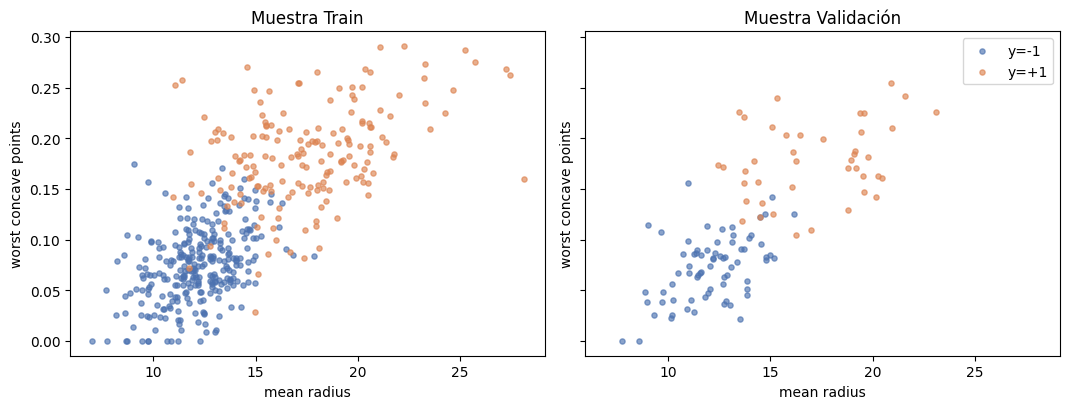

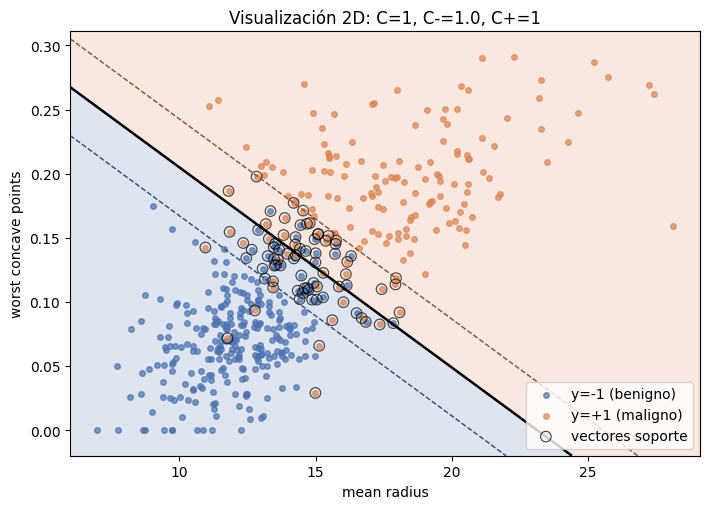

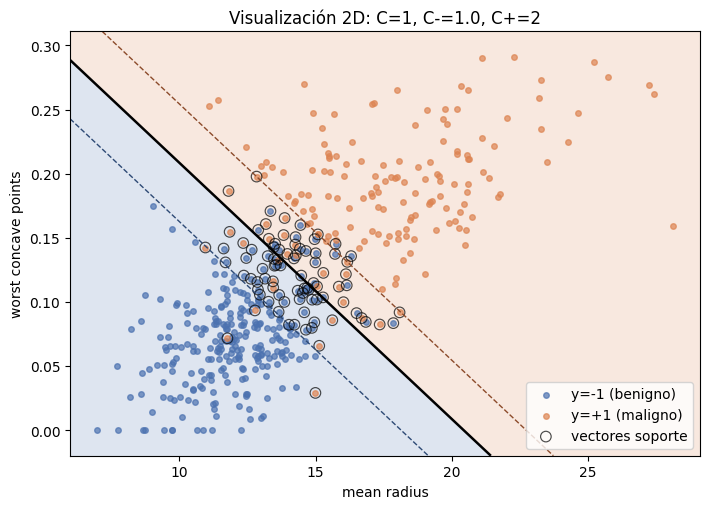

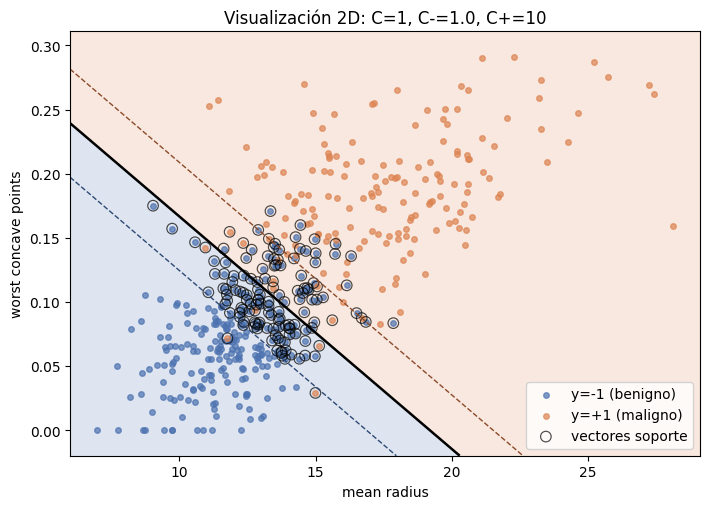

In [6]:
X_vis = X[['mean radius', 'worst concave points']].copy()  # Extrae dos dimensiones para visualización geométrica

X_vis_train, X_vis_val, y_vis_train, y_vis_val = train_test_split(  # Divide en train/val manteniendo proporciones de clase
    X_vis,  # Variables 2D para visualización
    y,  # Etiquetas binarias
    test_size=0.20,  # Mismo porcentaje de validación
    stratify=y,  # Conserva balance de clases
    random_state=RANDOM_STATE  # Reproducibilidad
)

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), sharex=True, sharey=True)  # Crea dos paneles para mostrar muestra train y val
for ax, (name, Xs, ys) in zip(axes, [('Train', X_vis_train, y_vis_train), ('Validación', X_vis_val, y_vis_val)]):  # Recorre ambos subconjuntos
    ax.scatter(Xs[ys == -1].iloc[:, 0], Xs[ys == -1].iloc[:, 1], s=14, c='#4C72B0', alpha=0.65, label='y=-1')  # Dibuja clase negativa
    ax.scatter(Xs[ys == 1].iloc[:, 0], Xs[ys == 1].iloc[:, 1], s=14, c='#DD8452', alpha=0.65, label='y=+1')  # Dibuja clase positiva
    ax.set_title(f'Muestra {name}')  # Título de cada panel
    ax.set_xlabel('mean radius')  # Etiqueta del eje x
    ax.set_ylabel('worst concave points')  # Etiqueta del eje y
axes[-1].legend(loc='best')  # Añade leyenda en el panel derecho
plt.tight_layout()  # Ajusta espaciado de subplots
plt.show()  # Muestra paneles train/val

C = 1.0  # Fija penalización global del soft-SVM
C_minus = 1.0  # Fija peso de clase negativa
C_plus_demo = [1, 2.0, 10.0]  # Define los tres valores de C+ a comparar

for cp in C_plus_demo:  # Recorre los tres escenarios de penalización positiva
    model_demo = svm_lineal_train(X_vis_train, y_vis_train, C=C, C_plus=cp, C_minus=C_minus)  # Entrena cada modelo en train 2D
    plotter(model_demo, X_vis_train, y_vis_train, title=f'Visualización 2D: C=1, C-={C_minus}, C+={cp:g}')  # Dibuja frontera/márgenes/SV sobre validación 2D

# 10) Experimento en validación variando $C_+$ (30 casos)

Volvemos al problema en **30 dimensiones** y variamos $C_+$ en 30 valores entre 0.5 y 15.

Criterio de evaluación:
- En validación minimizamos el **coste medio asimétrico**.
- También reportamos **recall** y **accuracy** para interpretar el comportamiento.

Efecto esperado:
- Subir $C_+$ suele aumentar recall de la clase positiva y reducir FN.
- Aun así, **más recall o menos FN no garantiza menor coste medio**, porque pueden crecer FP y el coste total depende de ambos errores.

,modelo,C_plus,recall_positivo,recall_negativo,FP,FN,coste_medio
0,modelo base (C+=1),1.0,0.904762,1.000000,0,4,0.350877
1,mejor modelo,2.0,0.952381,0.986111,1,2,0.184211
2,modelo C+=15,15.0,0.952381,0.944444,4,2,0.210526


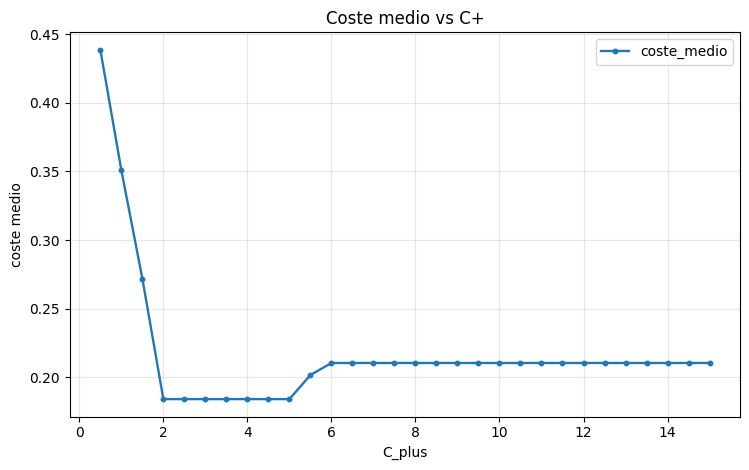

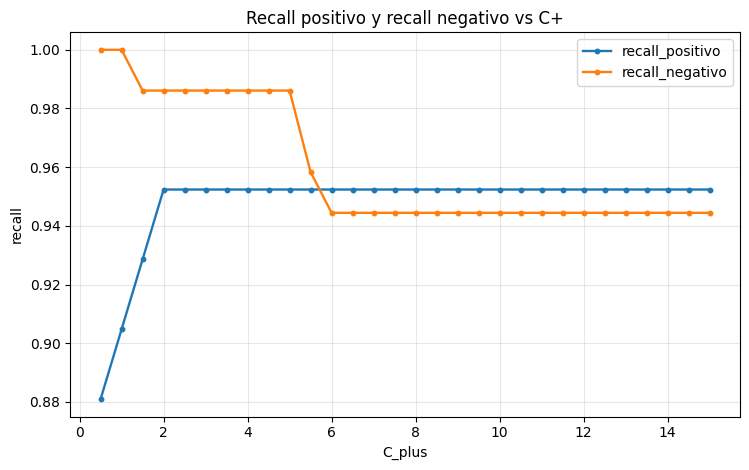

In [7]:
C = 1.0  # Fija penalización global del soft-SVM
C_minus = 1.0  # Fija peso de la clase negativa como referencia
C_plus_values = list(np.linspace(0.5, 15.0, 30))  # Define 30 valores de C+ sin incluir C+=0

rows = []  # Acumula resultados de cada experimento para tabla y gráfica
best_model = None  # Guardará el mejor modelo encontrado
best_cost = np.inf  # Inicializa con infinito para poder minimizar

for C_plus in C_plus_values:  # Recorre cada configuración de peso positivo
    model = svm_lineal_train(X_train, y_train, C=C, C_plus=C_plus, C_minus=C_minus)  # Entrena modelo con parámetros actuales en 30D
    met = evalua_modelo(model, X_val, y_val, cfn=CFN, cfp=CFP)  # Evalúa el modelo en validación
    rows.append({'C_plus': float(C_plus), **met, 'model': model})  # Guarda métricas y modelo para análisis posterior
    if met['coste_medio'] < best_cost:  # Comprueba si mejora el mejor coste observado
        best_cost = met['coste_medio']  # Actualiza mejor coste
        best_model = model  # Actualiza referencia al mejor modelo

df_all = pd.DataFrame(rows).sort_values('C_plus').reset_index(drop=True)  # Crea tabla ordenada por C+
df_res = df_all.drop(columns='model')  # Tabla pública sin objetos de modelo

df_res['recall_negativo'] = df_res['TN'] / (df_res['TN'] + df_res['FP'])  # Calcula recall de la clase negativa

best_idx = int(df_res['coste_medio'].idxmin())  # Encuentra fila con menor coste medio
best_c_plus = float(df_res.loc[best_idx, 'C_plus'])  # Extrae C+ óptimo

idx_base = int((df_res['C_plus'] - 1.0).abs().idxmin())  # Selecciona índice del modelo base C+=1
idx_top = int((df_res['C_plus'] - 15.0).abs().idxmin())  # Selecciona índice del modelo con C+=15
idx_display = sorted(set([idx_base, best_idx, idx_top]))  # Construye conjunto de filas a mostrar

df_display = df_res.loc[idx_display, ['C_plus', 'recall_positivo', 'recall_negativo', 'FP', 'FN', 'coste_medio']].copy()  # Deja solo columnas pedidas y relevantes
df_display['modelo'] = np.where(df_display['C_plus'] == 1.0, 'modelo base (C+=1)', np.where(df_display['C_plus'] == 15.0, 'modelo C+=15', 'mejor modelo'))  # Etiqueta cada fila

display(df_display[['modelo', 'C_plus', 'recall_positivo', 'recall_negativo', 'FP', 'FN', 'coste_medio']].sort_values('C_plus').reset_index(drop=True))  # Muestra solo base, mejor y C+=15

curva_generica(  # Gráfica 1: coste medio según C+
    x_values=df_res['C_plus'].values,  # Eje x con C+
    y_series={'coste_medio': df_res['coste_medio'].values},  # Serie única de coste medio
    x_label='C_plus',  # Etiqueta eje x
    y_label='coste medio',  # Etiqueta eje y
    title='Coste medio vs C+'  # Título de la primera gráfica
)

curva_generica(  # Gráfica 2: recalls positivo y negativo según C+
    x_values=df_res['C_plus'].values,  # Eje x con C+
    y_series={  # Dos series de recall
        'recall_positivo': df_res['recall_positivo'].values,
        'recall_negativo': df_res['recall_negativo'].values,
    },
    x_label='C_plus',  # Etiqueta eje x
    y_label='recall',  # Etiqueta eje y
    title='Recall positivo y recall negativo vs C+'  # Título de la segunda gráfica
)